# Energy Efficiency (UCI)

#### About the dataset

This dataset is used for predicting the heating and cooling requirements of buildings. The goal is understanding how different building design parameters affects the energy needed in order to heat or cool the building. 

* Application: Building design optimazation


#### Variables: 

- **X1 (Relative Compactness)**  <br><br>
Ratio of building volume to surface area where the higher the ration the more compact. <br><br>
- **X2 (Surface Area)** <br><br>
Total Surface Area <br><br>
- **X3 (Wall Area)** <br><br>
Total wall area <br><br>
- X4 **(Roof Area)** <br><br>
Total roof area <br><br>
- X5 **(Overall Height)** <br><br>
Building height <br><br>
- X6 **(Orientation)** <br><br>
Direction the building faces <br><br>
- X7 **(Glazing Area)** <br><br>
Total window area as percentage of floor area <br><br>
- X8 **(Glazing Area Distribution)** <br><br>
How windows are distributed on walls <br><br>
- Y1 **(Heating Load)**<br><br>
 Energy required to heat the building (kWh/$m^2$/year)<br><br>
- Y2 **(Cooling Load)**<br><br>
Energy required to cool the building.

## Coding

### EDA

In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import PartialDependenceDisplay


In [99]:
df = pd.read_excel("ENB2012_data.xlsx")

In [100]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


**Comment:** Our columns are in X and Y form we need to assign names to make it more readable

In [101]:
df.columns = [
    'Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
    'Overall_Height', 'Orientation', 'Glazing_Area',
    'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load'
]

In [102]:
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [103]:
print(df["Orientation"].unique())
print(df["Glazing_Area_Distribution"].unique())
print(df["Glazing_Area"].unique())


[2 3 4 5]
[0 1 2 3 4 5]
[0.   0.1  0.25 0.4 ]


In [104]:
# df = df.drop('Surface_Area', axis=1)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [106]:
df.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


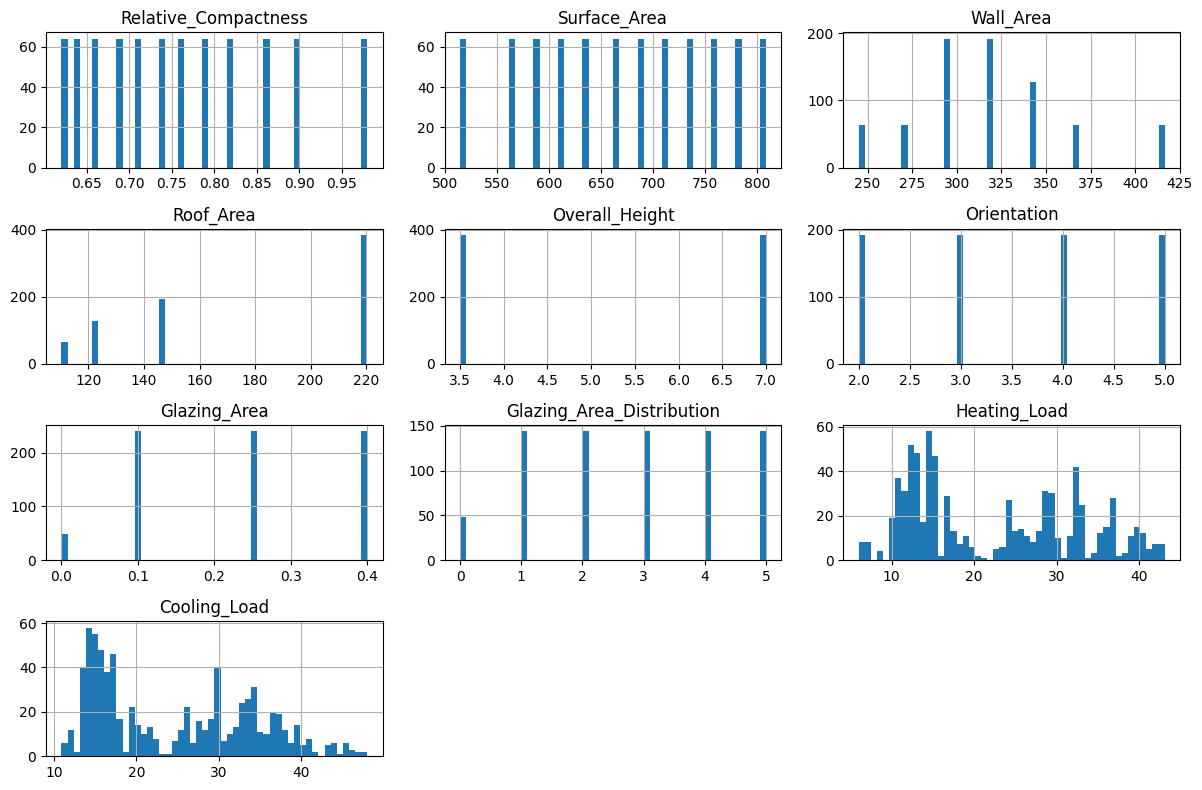

In [107]:
df.hist(bins=50, figsize=(12,8))
plt.tight_layout()
plt.show()

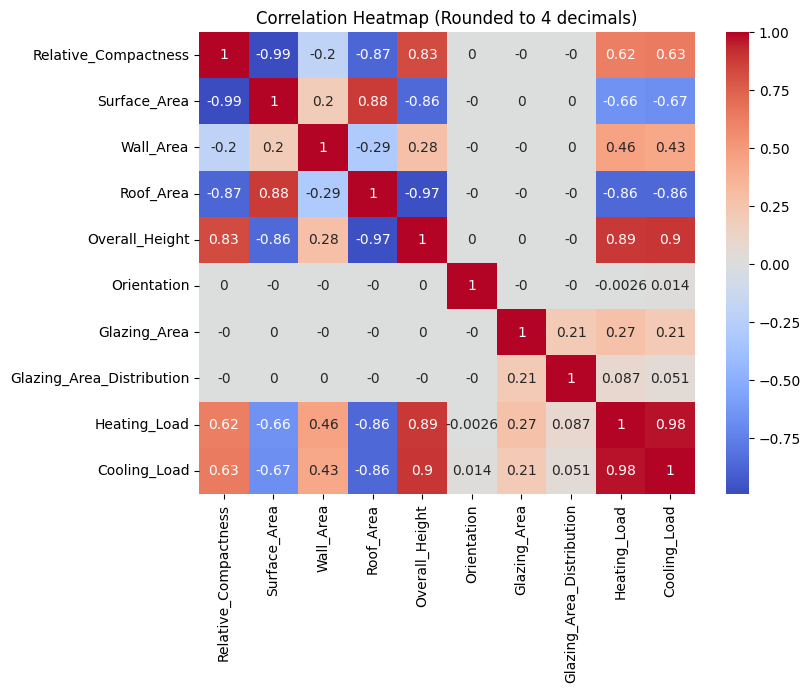

In [108]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr().round(4), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Rounded to 4 decimals)")
plt.show()

In [ ]:
# sns.pairplot(df, vars=['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
#     'Overall_Height', 'Orientation', 'Glazing_Area',
#     'Glazing_Area_Distribution'], hue='Heating_Load', palette='coolwarm')

# for more readability lets group by geometry and architecture
sns.pairplot(df, vars=['Heating_Load','Relative_Compactness','Wall_Area', 'Roof_Area', 
                       'Surface_Area'], hue='Heating_Load', palette='coolwarm')

plt.suptitle('Building Geometry Features (Heating)', y= 1.02)
plt.show()

- We can see that surface area has a strong correlation with other variables but surface area is also the total sum of the total area which makes it redudant so we might have to drop it to also address collinearity. 


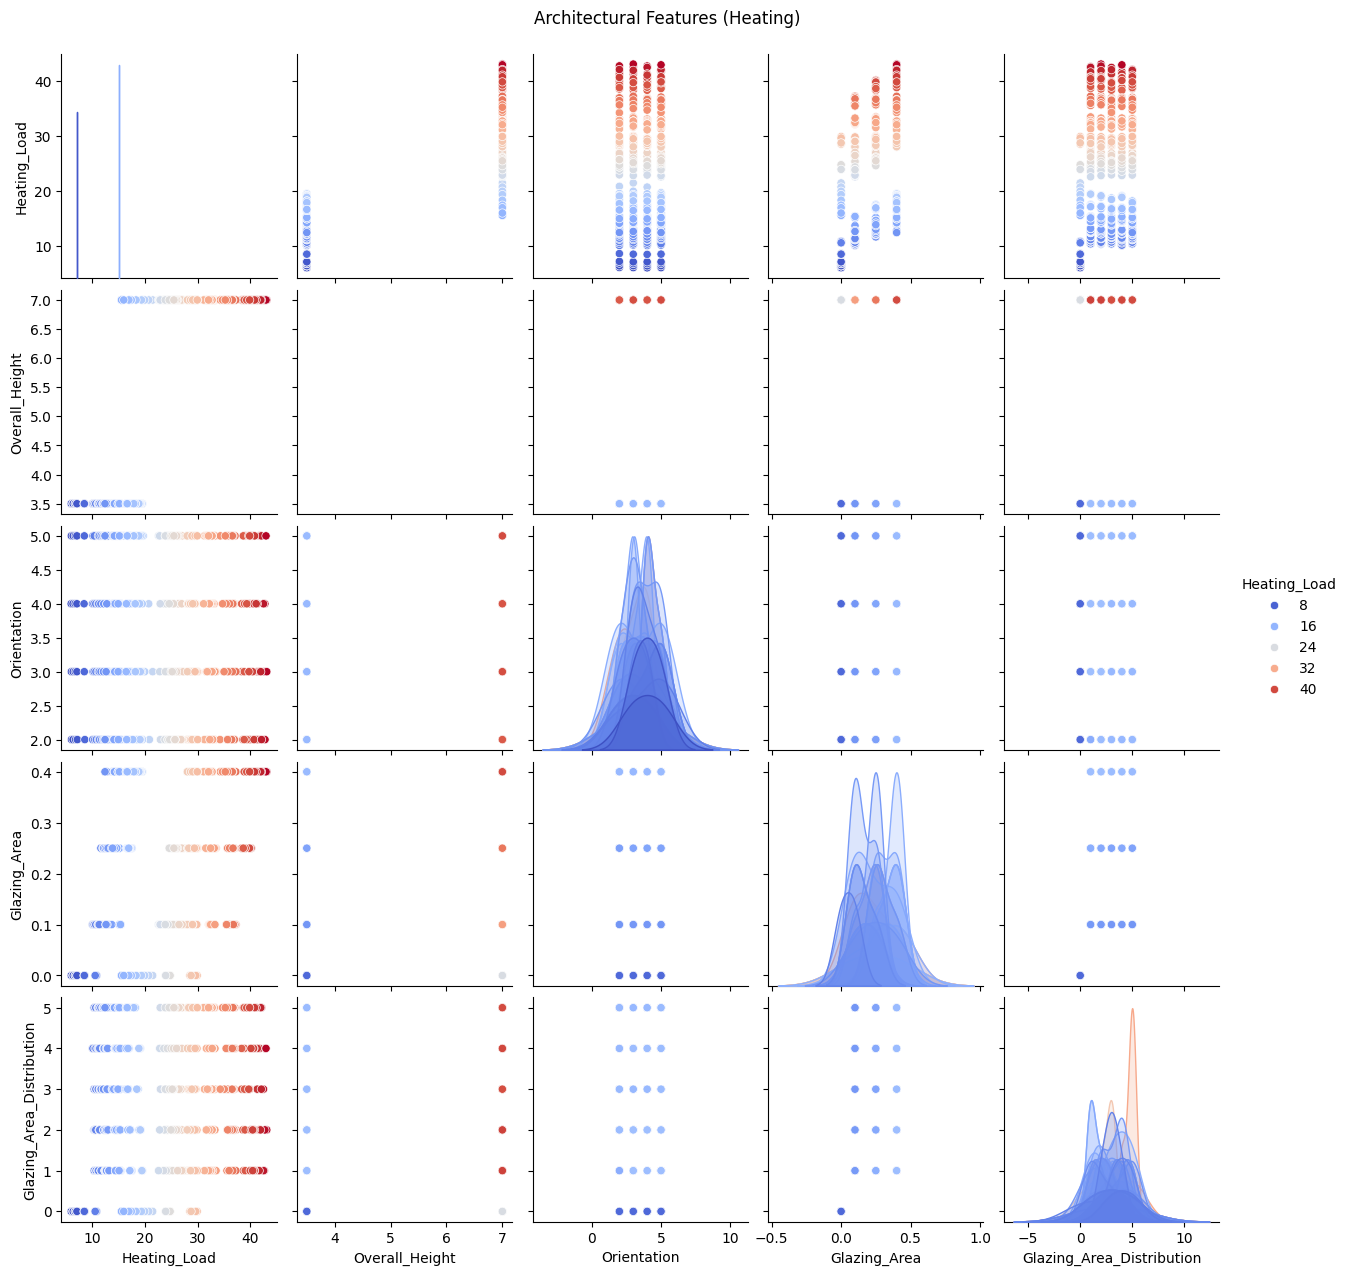

In [ ]:
sns.pairplot(df, vars=['Heating_Load','Overall_Height', 'Orientation', 'Glazing_Area',
    'Glazing_Area_Distribution'], hue='Heating_Load', palette='coolwarm')

plt.suptitle('Architectural Features (Heating)', y= 1.02)
plt.show()

- Orientation seems to have a very weak or not meaningful correlation with heat. We might need to drop this.
- The height seems to have a moderate positive correlation as well as the glazing area

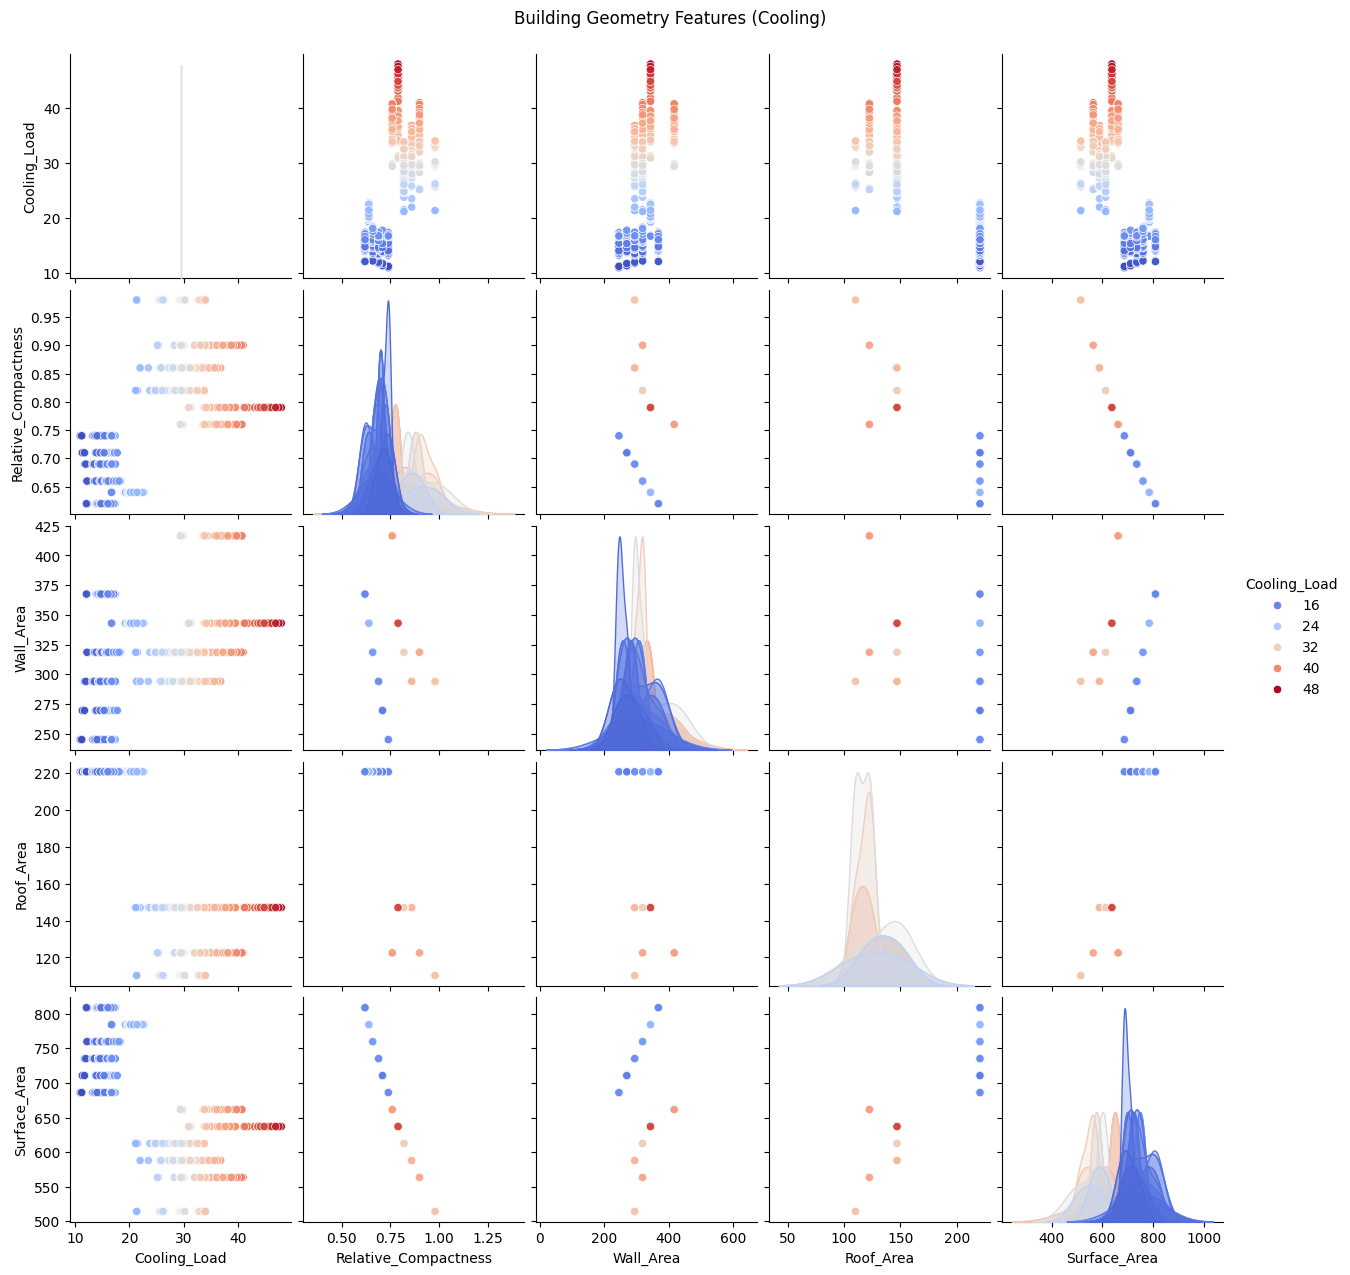

In [ ]:
sns.pairplot(df, vars=['Cooling_Load','Relative_Compactness','Wall_Area', 'Roof_Area', 
                       'Surface_Area'], hue='Cooling_Load', palette='coolwarm')

plt.suptitle('Building Geometry Features (Cooling)', y= 1.02)
plt.show()

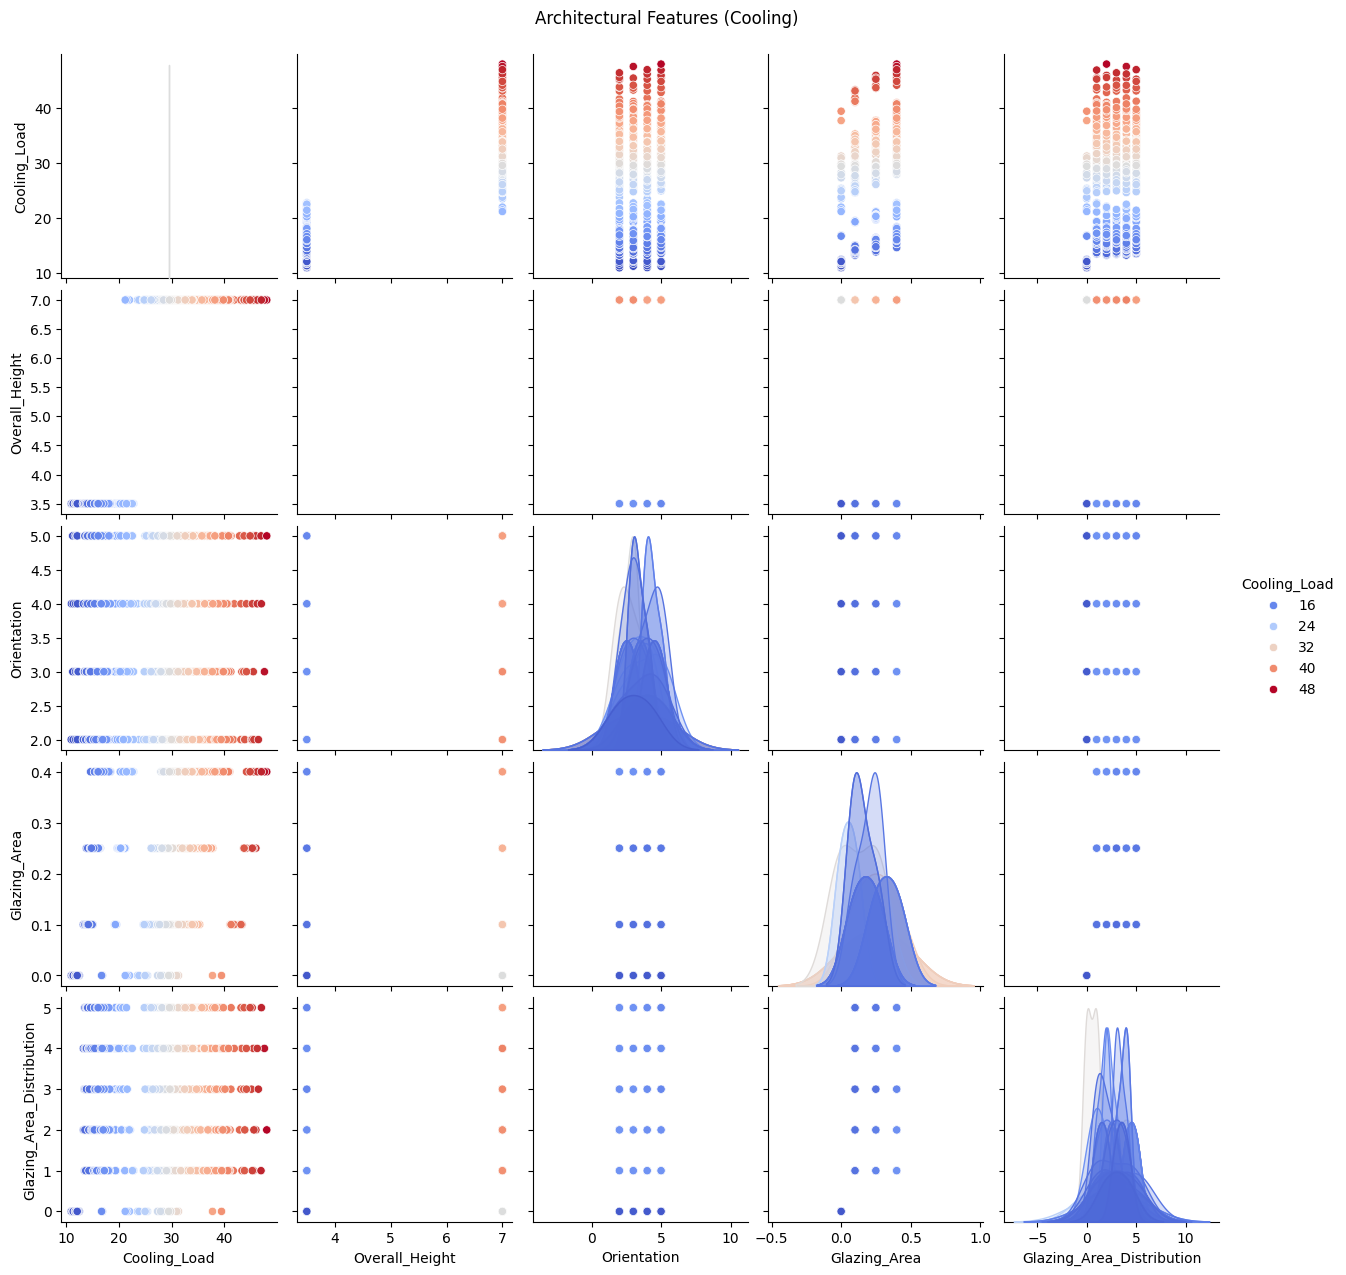

In [ ]:
sns.pairplot(df, vars=['Cooling_Load','Overall_Height', 'Orientation', 'Glazing_Area',
    'Glazing_Area_Distribution'], hue='Cooling_Load', palette='coolwarm')

plt.suptitle('Architectural Features (Cooling)', y= 1.02)
plt.show()

- We get simmilar conclusions for cooling. 

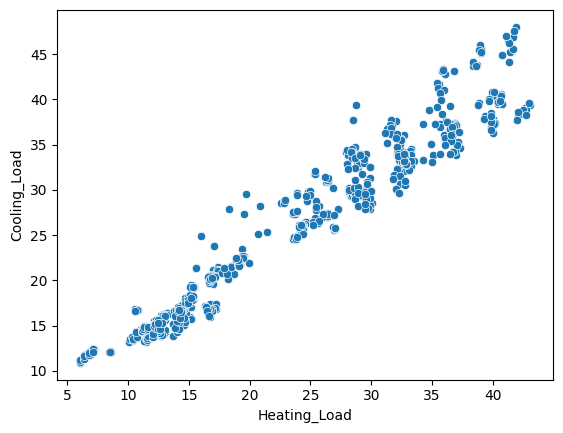

In [ ]:
sns.scatterplot(x='Heating_Load', y='Cooling_Load', data=df)
plt.show()

In [ ]:
# Dropping surface area
df.drop(['Surface_Area'], axis=1, inplace=True)

- Lets take a further look at orientation to see if it has a strong impact against heating and cooling

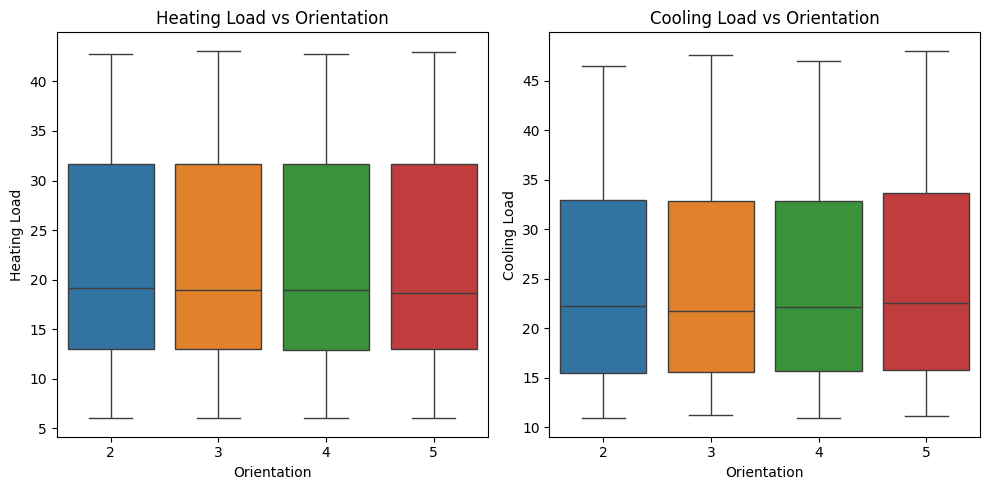

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# heating
plt.subplot(1, 2, 1)
sns.boxplot(x='Orientation', y='Heating_Load', hue='Orientation',palette='tab10', legend=False, data=df)
plt.title('Heating Load vs Orientation')
plt.ylabel('Heating Load')

# cooling
plt.subplot(1, 2, 2)
sns.boxplot(x='Orientation', y='Cooling_Load',hue='Orientation',palette='tab10', legend=False, data=df)
plt.title('Cooling Load vs Orientation')
plt.ylabel('Cooling Load')

plt.tight_layout()
plt.show()


- We can see that orientation has no impact for heating and cooling. Therefore, we can also drop this feature to simplify our model.

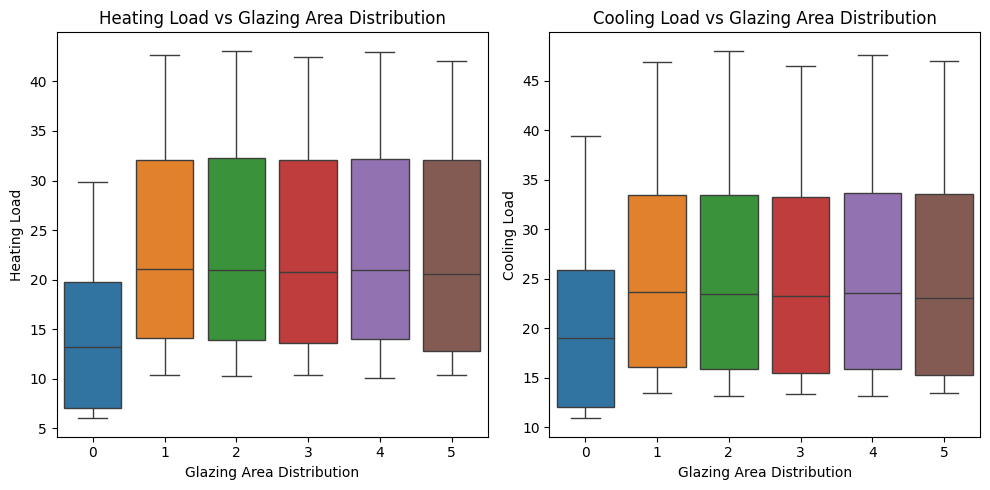

In [ ]:
plt.figure(figsize=(10, 5))

# heating
plt.subplot(1, 2, 1)
sns.boxplot(x='Glazing_Area_Distribution', y='Heating_Load', hue='Glazing_Area_Distribution',palette='tab10', legend=False, data=df)
plt.title('Heating Load vs Glazing Area Distribution')
plt.xlabel('Glazing Area Distribution')
plt.ylabel('Heating Load')


# cooling
plt.subplot(1, 2, 2)
sns.boxplot(x='Glazing_Area_Distribution', y='Cooling_Load',hue='Glazing_Area_Distribution',palette='tab10', legend=False, data=df)
plt.title('Cooling Load vs Glazing Area Distribution')
plt.xlabel('Glazing Area Distribution')
plt.ylabel('Cooling Load')

plt.tight_layout()
plt.show()

- We can see that only type 0 has an impact for heating and cooling but for future models we are going to leave it. This means that no glazing anywhere has big impact it does not matter for the rest. 

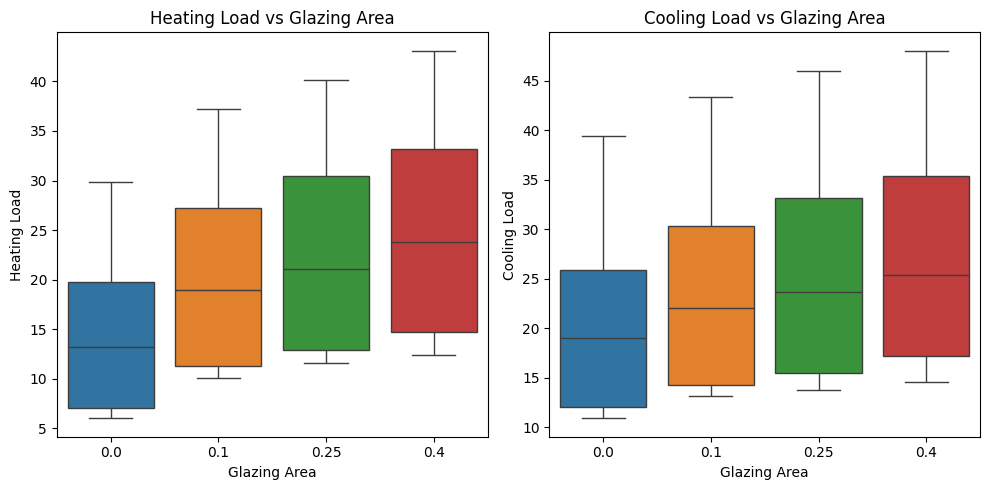

In [ ]:
plt.figure(figsize=(10, 5))

# heating
plt.subplot(1, 2, 1)
sns.boxplot(x='Glazing_Area', y='Heating_Load', hue='Glazing_Area',palette='tab10', legend=False, data=df)
plt.title('Heating Load vs Glazing Area')
plt.xlabel('Glazing Area')
plt.ylabel('Heating Load')


# cooling
plt.subplot(1, 2, 2)
sns.boxplot(x='Glazing_Area', y='Cooling_Load',hue='Glazing_Area',palette='tab10', legend=False, data=df)
plt.title('Cooling Load vs Glazing Area')
plt.xlabel('Glazing Area')
plt.ylabel('Cooling Load')

plt.tight_layout()
plt.show()

- For Glazing Area we can see that the higher the percentage the hotter it gets but also the cooler it gets. 

### Model

#### Linear Regression

In [ ]:
heating_formula = "Heating_Load ~ Relative_Compactness  + Wall_Area + Roof_Area + Overall_Height + Glazing_Area + Glazing_Area_Distribution"
cooling_formula = "Cooling_Load ~ Relative_Compactness + Wall_Area + Roof_Area + Overall_Height + Glazing_Area + Glazing_Area_Distribution"

# Fitting models
lm_heating = ols(heating_formula, data=df).fit()
lm_cooling = ols(cooling_formula, data=df).fit()


In [ ]:
print(lm_heating.summary())

                            OLS Regression Results                            
Dep. Variable:           Heating_Load   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     1387.
Date:                Fri, 28 Nov 2025   Prob (F-statistic):               0.00
Time:                        19:06:27   Log-Likelihood:                -1912.5
No. Observations:                 768   AIC:                             3839.
Df Residuals:                     761   BIC:                             3871.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

**Heating**

- Most of the variables are statistically significant except for Roof_Area which it is still significnant but not as strong as the other variables. 
- The R-squared is high with 91% of the model being explained and the Adj R-square is identically.  
- F-statistics shows that our model is highly significant.
- Some of our tests such as Jarque-Bera show us that the residuals are not normaly distributed (Ideally should be greater than 0.05)
- Durbin-Watson shows a strong positive autocorrelation (ideally should be between 1.5 to 2.5)
- Omnibus confirms non-normally  (Ideally should be greater than 0.05)

**Comments**: Even though both models have a strong predictive accuracy statistical inference is not reliaable since there are some assumption violations. 

In [ ]:
print(lm_cooling.summary())

                            OLS Regression Results                            
Dep. Variable:           Cooling_Load   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     1002.
Date:                Fri, 28 Nov 2025   Prob (F-statistic):               0.00
Time:                        19:06:27   Log-Likelihood:                -1980.0
No. Observations:                 768   AIC:                             3974.
Df Residuals:                     761   BIC:                             4007.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

**Cooling**
- For also most of the variables are statiscally significant except for Glazing Area Distribution. 
- We also have a slightly lower but still strong R-squared and Adj. R-squared
- Other tests also indicates autocorrelation and non-normal residuals. 

**Comments**: Even though both models have a strong predictive accuracy statistical inference is not reliaable since there are some assumption violations. 

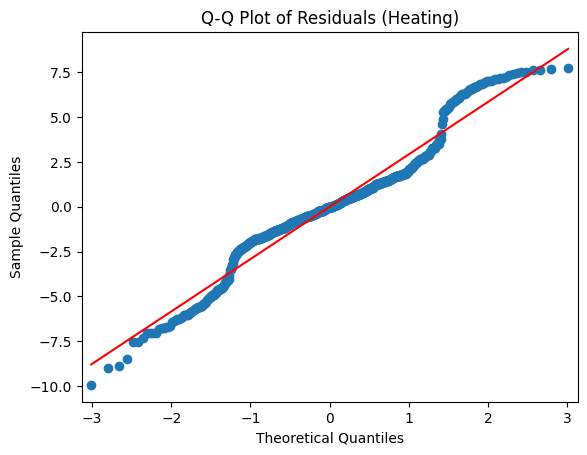

In [ ]:
# Heating load Q-Q plot
residuals_heating = lm_heating.resid
sm.qqplot(residuals_heating, line='s')
plt.title("Q-Q Plot of Residuals (Heating)")
plt.show()

In [ ]:
import scipy.stats as stats
# --- Shapiro–Wilk Test ---
shapiro_stat, shapiro_p = stats.shapiro(residuals_heating)

print("Shapiro-Wilk Test:")
print(f"Statistic: {shapiro_stat:.4f}")
print(f"P-value:   {shapiro_p:.4g}")


Shapiro-Wilk Test:
Statistic: 0.9542
P-value:   1.006e-14


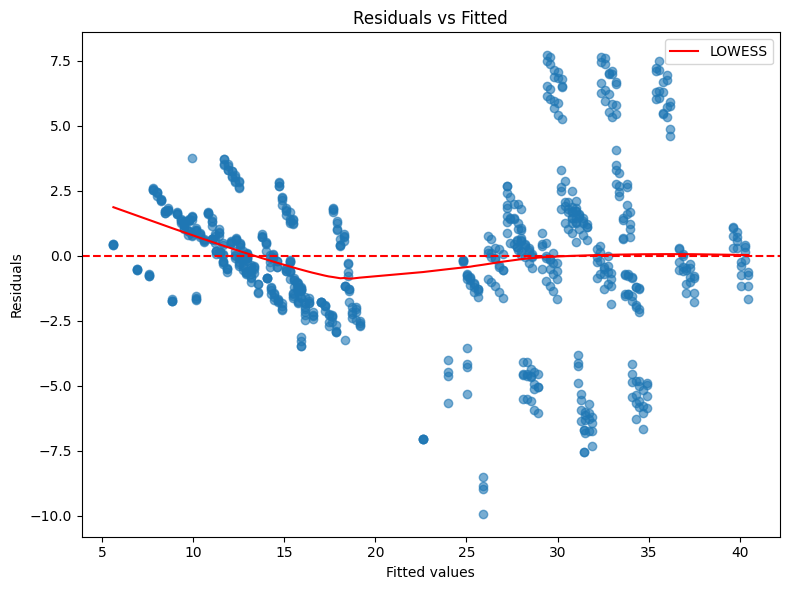

In [ ]:
# Residuals vs Fitted with LOWESS
plt.figure(figsize=(8, 6))
plt.scatter(lm_heating.fittedvalues, lm_heating.resid, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

# LOWESS line
lowess = sm.nonparametric.lowess(lm_heating.resid, lm_heating.fittedvalues)

plt.plot(lowess[:, 0], lowess[:, 1], color='red', linewidth=1.5, label='LOWESS')

plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (Heating Load)')
plt.legend()
plt.tight_layout()
plt.show()

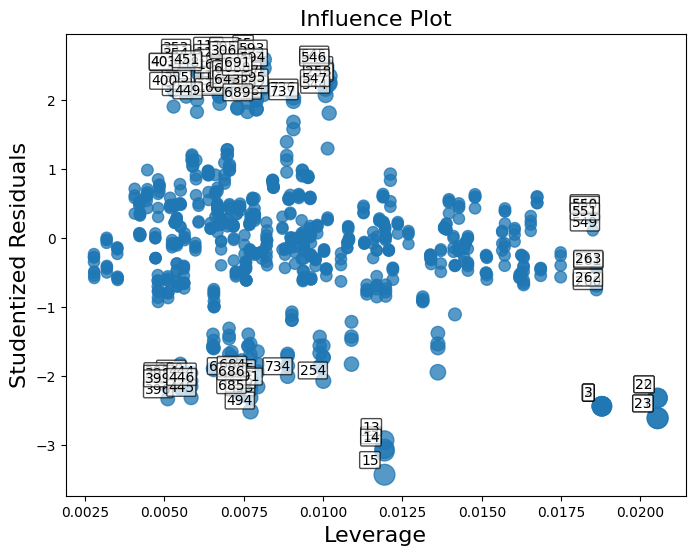

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

sm.graphics.influence_plot(lm_heating, criterion="cooks", size=20, ax=ax, alpha=0.05)

# arranging text for better fit 
for text in ax.texts:
    text.set_fontsize(10)  
    text.set_ha('center')
    text.set_va('center')
    #background for readability
    text.set_bbox(dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7))
plt.show()

In [ ]:
heating_transformed, heating_lambda = stats.boxcox(df["Heating_Load"])
print(heating_lambda)

0.15693628225179065


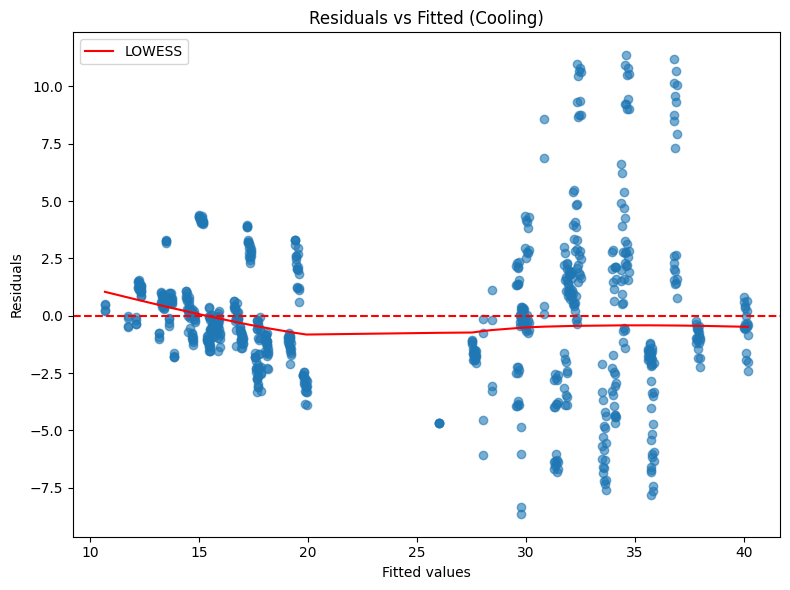

In [ ]:
# Residuals vs Fitted with LOWESS
plt.figure(figsize=(8, 6))
plt.scatter(lm_cooling.fittedvalues, lm_cooling.resid, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

# LOWESS line
lowess = sm.nonparametric.lowess(lm_cooling.resid, lm_cooling.fittedvalues)

plt.plot(lowess[:, 0], lowess[:, 1], color='red', linewidth=1.5, label='LOWESS')

plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (Cooling Load)')
plt.legend()
plt.tight_layout()
plt.show()

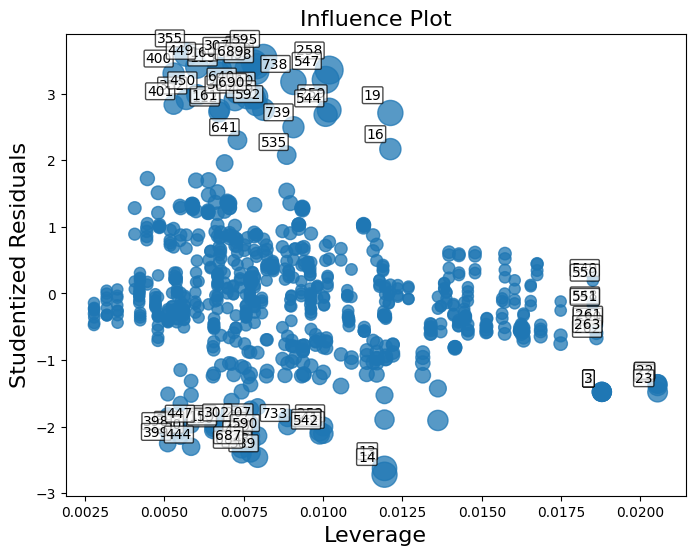

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

sm.graphics.influence_plot(lm_cooling, criterion="cooks", size=20, ax=ax)

# arranging text for better fit 
for text in ax.texts:
    text.set_fontsize(10)  
    text.set_ha('center')
    text.set_va('center')
    #background for readability
    text.set_bbox(dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7))
plt.show()

Side by side plots for write-up

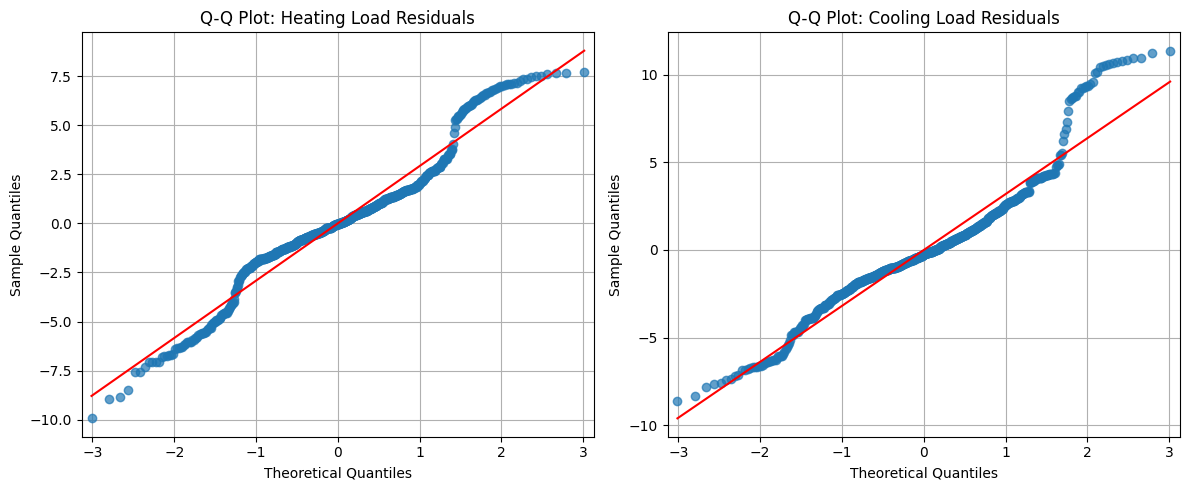

In [ ]:
# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Heating load Q-Q plot
residuals_heating = lm_heating.resid
sm.qqplot(residuals_heating, line='s', ax=ax1, alpha=0.7)
ax1.set_title("Q-Q Plot: Heating Load Residuals")


# Cooling load Q-Q plot
residuals_cooling = lm_cooling.resid
sm.qqplot(residuals_cooling, line='s', ax=ax2, alpha=0.7)
ax2.set_title("Q-Q Plot: Cooling Load Residuals")

ax1.grid()
ax2.grid()
plt.tight_layout()
plt.show()

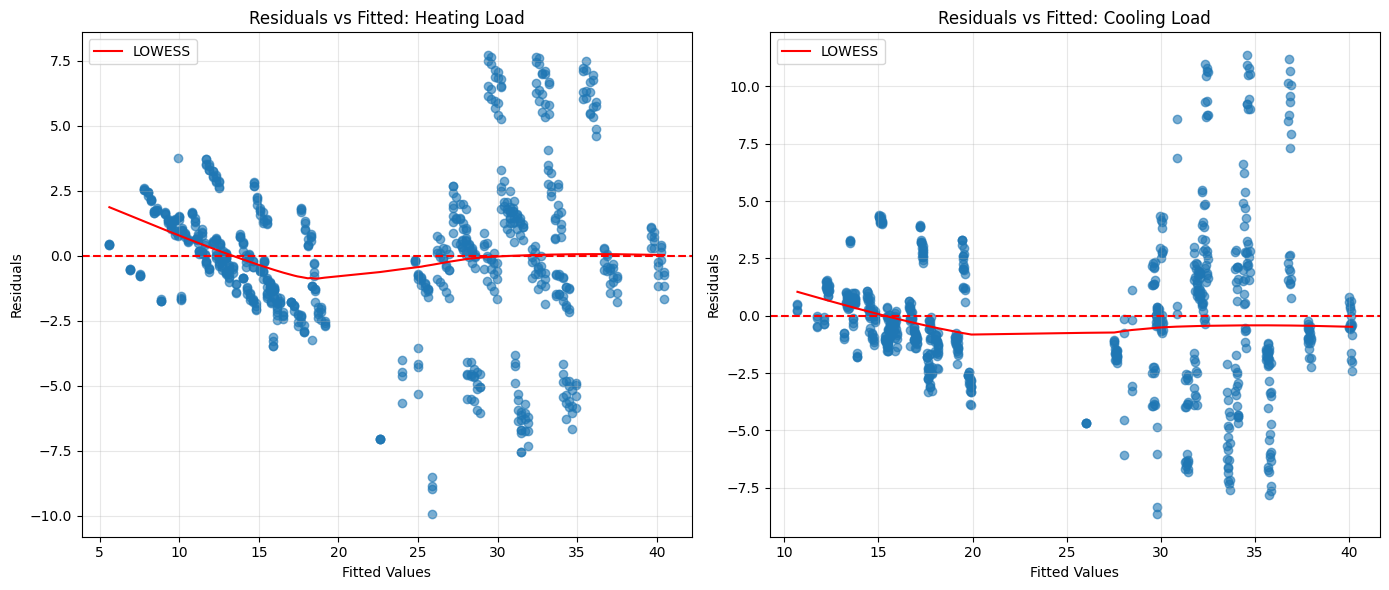

In [ ]:

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Heating model residuals vs fitted
scatter1 = ax1.scatter(lm_heating.fittedvalues, lm_heating.resid, alpha=0.6)
ax1.axhline(y=0, color='red', linestyle='--')

lowess_heating = sm.nonparametric.lowess(lm_heating.resid, lm_heating.fittedvalues)

ax1.plot(lowess_heating[:, 0], lowess_heating[:, 1], color='red', linewidth=1.5, label='LOWESS')
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted: Heating Load')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Cooling model residuals vs fitted
scatter2 = ax2.scatter(lm_cooling.fittedvalues, lm_cooling.resid, alpha=0.6)

ax2.axhline(y=0, color='red', linestyle='--')

lowess_cooling = sm.nonparametric.lowess(lm_cooling.resid, lm_cooling.fittedvalues)

ax2.plot(lowess_cooling[:, 0], lowess_cooling[:, 1], color='red', linewidth=1.5, label='LOWESS')
ax2.set_xlabel('Fitted Values')
ax2.set_ylabel('Residuals')
ax2.set_title('Residuals vs Fitted: Cooling Load')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuals_vs_fitted.png', dpi=300, bbox_inches='tight')
plt.show()

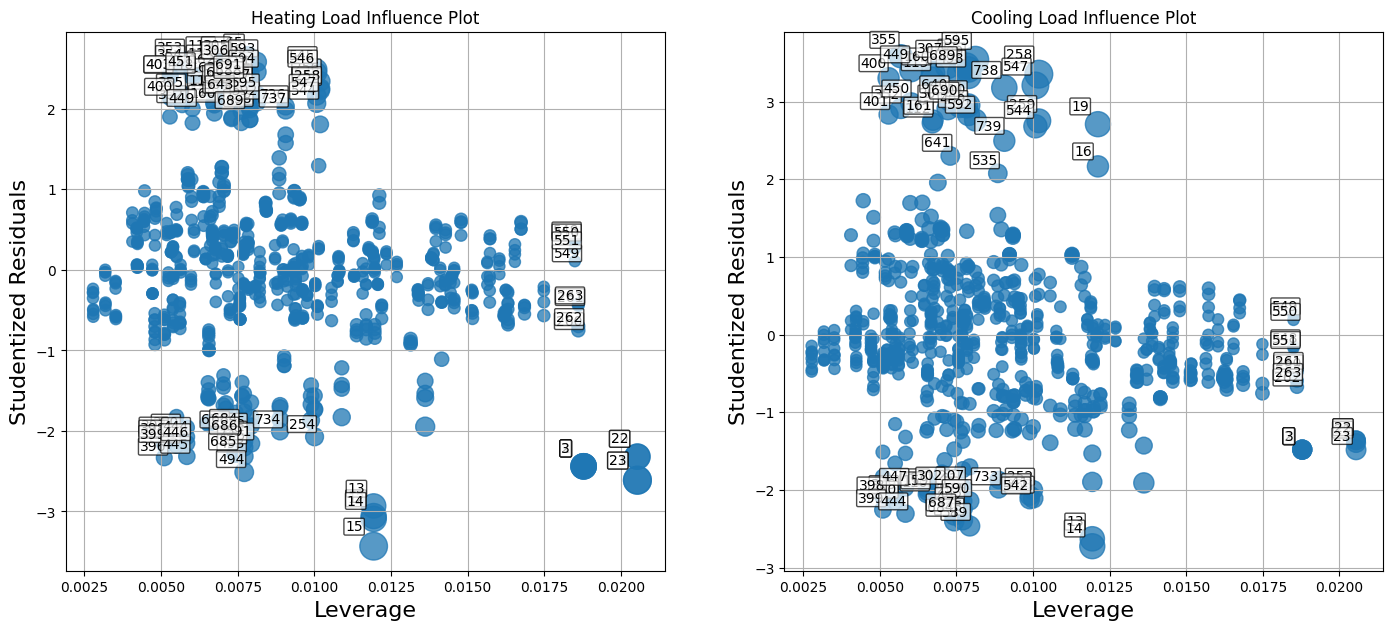

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))

sm.graphics.influence_plot(lm_heating, criterion="cooks", size=20, ax=ax1, alpha=0.05)
sm.graphics.influence_plot(lm_cooling, criterion="cooks", size=20, ax=ax2, alpha=0.05)

ax1.set_title("Heating Load Influence Plot")
ax1.grid()

ax2.set_title("Cooling Load Influence Plot")
ax2.grid()
# arranging text for better fit 
for text in ax1.texts:
    text.set_fontsize(10)  
    text.set_ha('center')
    text.set_va('center')
    #background for readability
    text.set_bbox(dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7))

for text in ax2.texts:
    text.set_fontsize(10)  
    text.set_ha('center')
    text.set_va('center')
    #background for readability
    text.set_bbox(dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7))
    
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Wall_Area                  768 non-null    float64
 2   Roof_Area                  768 non-null    float64
 3   Overall_Height             768 non-null    float64
 4   Orientation                768 non-null    int64  
 5   Glazing_Area               768 non-null    float64
 6   Glazing_Area_Distribution  768 non-null    int64  
 7   Heating_Load               768 non-null    float64
 8   Cooling_Load               768 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


### Regression Models

#### Linear Regression

In [ ]:
# assigning features and target variables
X = df[['Relative_Compactness', 'Wall_Area', 'Roof_Area', 
        'Overall_Height', 'Glazing_Area', 'Glazing_Area_Distribution']]

y_heating = df["Heating_Load"]
y_cooling = df["Cooling_Load"]

# Train split data
X_train, X_test, y1_train, y1_test = train_test_split(X, y_heating, test_size=0.2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X, y_cooling, test_size=0.2, random_state=42)

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled2 = scaler.transform(X2_train)
X_test_scaled2 = scaler.transform(X2_test)

##### Linear Regression Heating

In [ ]:
linreg = LinearRegression()
linreg.fit(X_train_scaled, y1_train)

pred1 = linreg.predict(X_test_scaled)

print("R2:", r2_score(y1_test, pred1))
print("RMSE:", mean_squared_error(y1_test, pred1))


R2: 0.9122131164945246
RMSE: 9.15023837111948


##### Linear Regression Cooling 

In [ ]:
linreg2 = LinearRegression().fit(X_train_scaled2, y2_train)

pred2 = linreg2.predict(X_test_scaled2)

print("R2:", r2_score(y2_test, pred2))
print("RMSE:", mean_squared_error(y2_test, pred2))

R2: 0.8926669863195607
RMSE: 9.945180471161322


#### Random Forest

##### Random Forest Heating

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y1_train)

pred_rf = rf.predict(X_test)

print("R2:", r2_score(y1_test, pred_rf))

R2: 0.9974416912077896


[0.48314901 0.23939118 0.13489283 0.0798134  0.05102121 0.01173237]


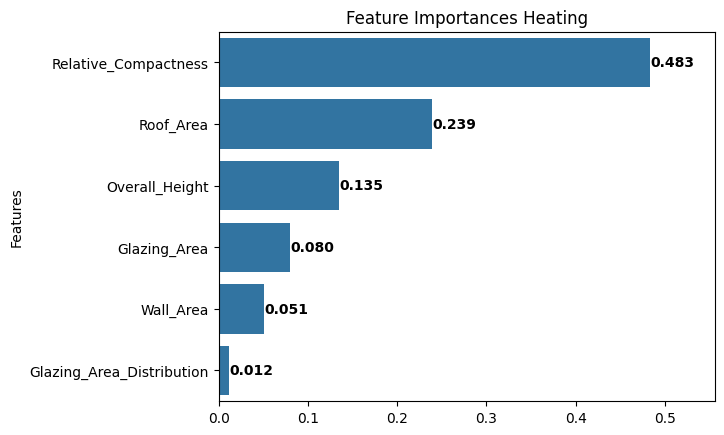

In [ ]:
idx = np.argsort(rf.feature_importances_)[::-1] 
print(rf.feature_importances_[idx])

feature_imp_sorted = rf.feature_importances_[idx]
feature_names_sorted = X.columns[idx]

ax = sns.barplot(x=feature_imp_sorted, y=feature_names_sorted)
plt.title("Feature Importances Heating")
plt.ylabel("Features")
# adding exact values for features
container = ax.containers[0]
ax.bar_label(container, fmt='%.3f', color='black', fontweight='bold')

# Adding some extra space for x to accomodate the values
max_value = max(feature_imp_sorted)
ax.set_xlim(0, max_value * 1.15)  
plt.show()

##### Random Forest Cooling

In [ ]:
# Random forest for Cooling 
rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf2.fit(X2_train, y2_train)

pred_rf2 = rf2.predict(X2_test)

print("R2:", r2_score(y2_test, pred_rf2))

R2: 0.9485439219632412


[0.4414894  0.36709772 0.06794891 0.06220605 0.0497604  0.01149752]


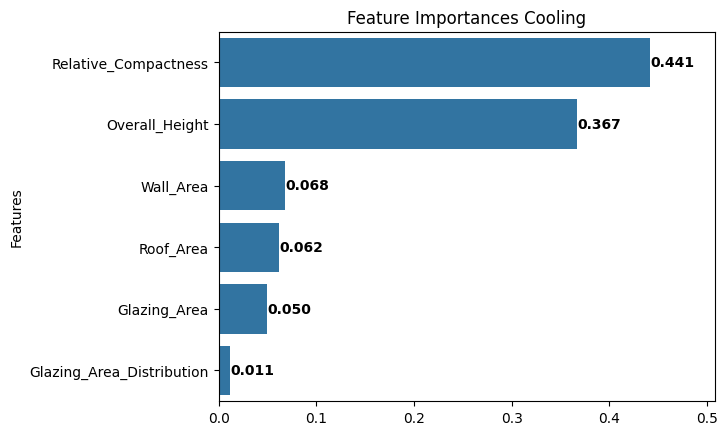

In [ ]:
idx2 = np.argsort(rf2.feature_importances_)[::-1] 
print(rf2.feature_importances_[idx2])

feature_imp_sorted2 = rf2.feature_importances_[idx2]
feature_names_sorted2 = X.columns[idx2]

# barplot
ax2 = sns.barplot(x=feature_imp_sorted2, y=feature_names_sorted2)
plt.title("Feature Importances Cooling")
plt.ylabel("Features")
# adding exact values for features
container2 = ax2.containers[0]
ax2.bar_label(container2, fmt='%.3f', color='black', fontweight='bold')

# Adding some extra space for x to accomodate the values
max_value2 = max(feature_imp_sorted2)
ax2.set_xlim(0, max_value2 * 1.15)  

plt.show()

### Visualizations for models

In [ ]:
# Defining the models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(alpha=0.1),
    'Ridge': Ridge(alpha=1.0)   
}

# function to train & predict for both scaled and unscaled inputs
def train_and_predict(models, X_train, X_test, X_train_scaled, X_test_scaled, y_train):

    # store predictions
    predictions = {}

    # iterating through each model based on the criteria (named, scaled)
    for name, model in models.items():
        
        # Scaled models
        if name in ['Lasso', 'Ridge']:
            model.fit(X_train_scaled, y_train)
            predictions[name] = model.predict(X_test_scaled)

        # Unscaled models
        else:
            model.fit(X_train, y_train)
            predictions[name] = model.predict(X_test)

    return predictions


# heating train and prediction
results_heating = train_and_predict(
    models,
    X_train, X_test,
    X_train_scaled, X_test_scaled,
    y1_train
)

# cooling train and prediction
results_cooling = train_and_predict(
    models,
    X2_train, X2_test,
    X_train_scaled2, X_test_scaled2,
    y2_train
)

In [ ]:
# Function to calculate metrics and return it for latter plotting 
def calculate_metrics(y_true, predictions):

    # storing metrics
    metrics = {}

    # computing metrics for R^2, MAE RMSE
    for name, y_pred in predictions.items():
        metrics[name] = {
            'R^2': r2_score(y_true, y_pred),
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
        }

    return metrics

# Defining plot function after computing metrics
def plot_performance(metrics, title):
    # size of plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metric_names = ['R^2', 'MAE', 'RMSE']

    # iterate through each metric and name 
    for i, metric in enumerate(metric_names):
        # extract miodel
        values = [metrics[name][metric] for name in models.keys()]
        # create barplot
        bars = axes[i].bar(models.keys(), values, color=['green','blue','orange','red'])
        
        # set main and y title for each metric
        # convert to math notation 
        if metric == 'R^2':
            axes[i].set_title(f'$R^2$ Comparison') 
            axes[i].set_ylabel('$R^2$') 
        else:
            axes[i].set_title(f'{metric} Comparison')
            axes[i].set_ylabel(metric)

        # adding labels and making it even
        for bar, value in zip(bars, values):
            axes[i].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() ,
                         f'{value:.2f}',
                         ha='center', va='bottom')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

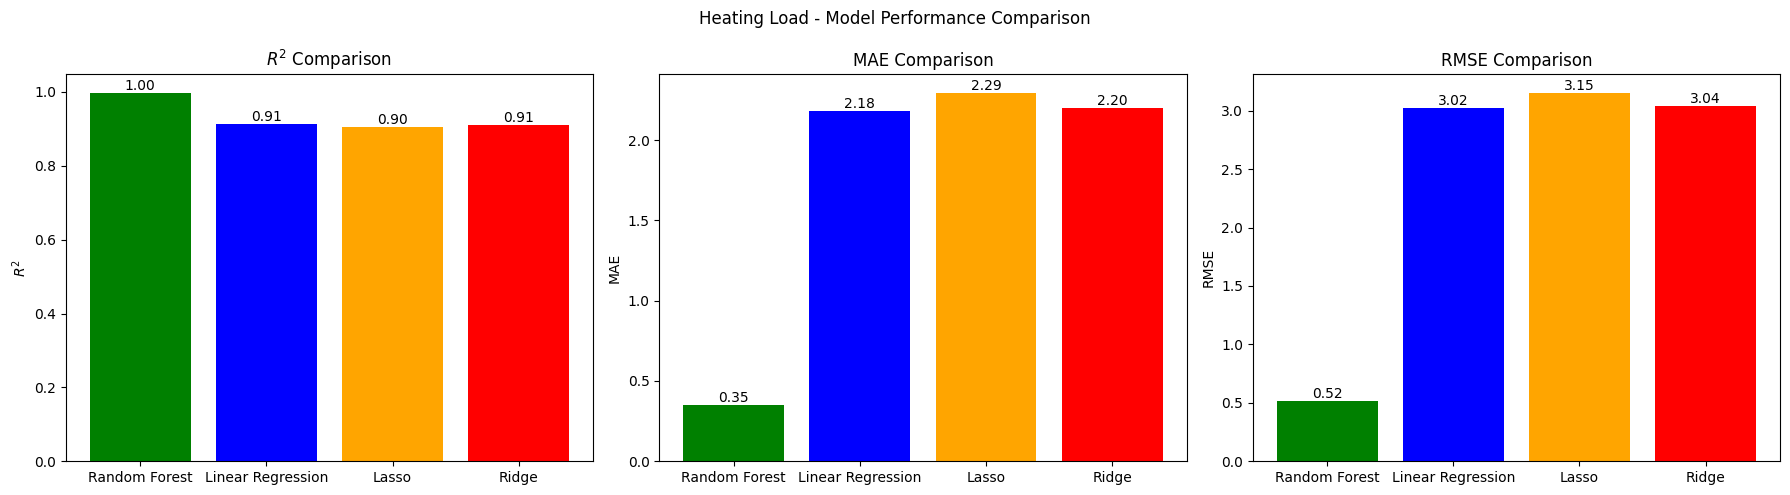

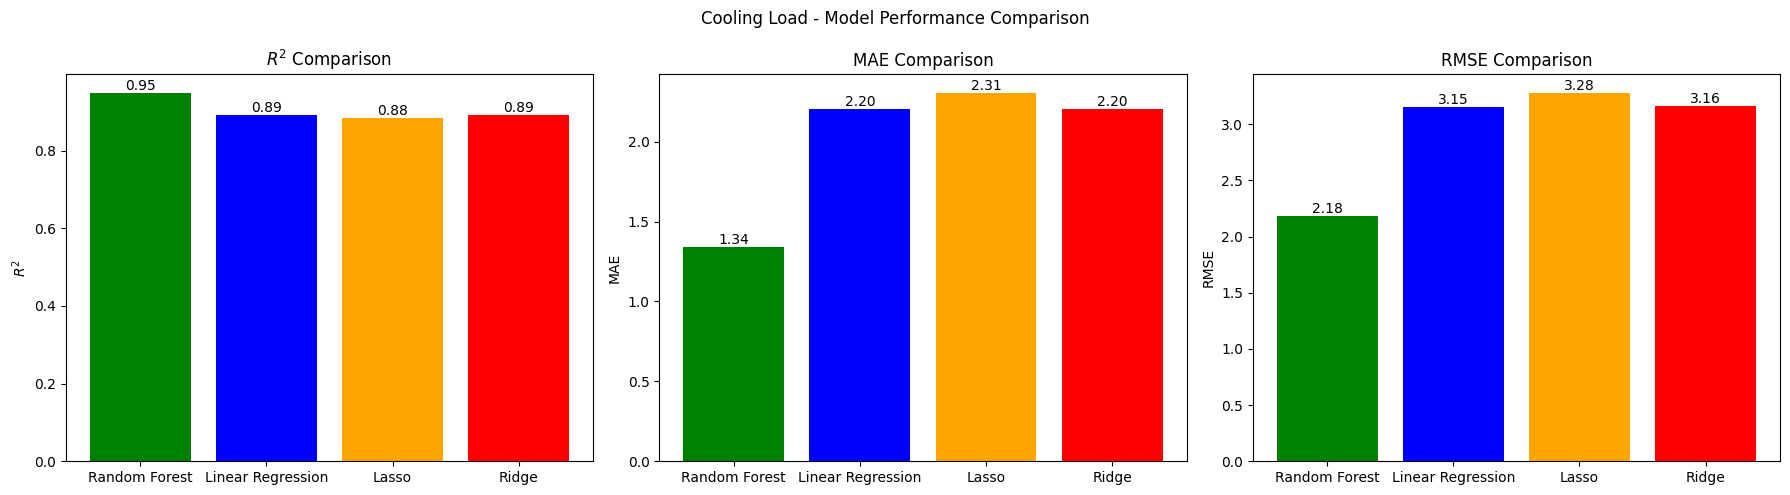

In [ ]:
# Plot results
metrics_heating = calculate_metrics(y1_test, results_heating)
metrics_cooling = calculate_metrics(y2_test, results_cooling)

plot_performance(metrics_heating, "Heating Load - Model Performance Comparison")
plot_performance(metrics_cooling, "Cooling Load - Model Performance Comparison")

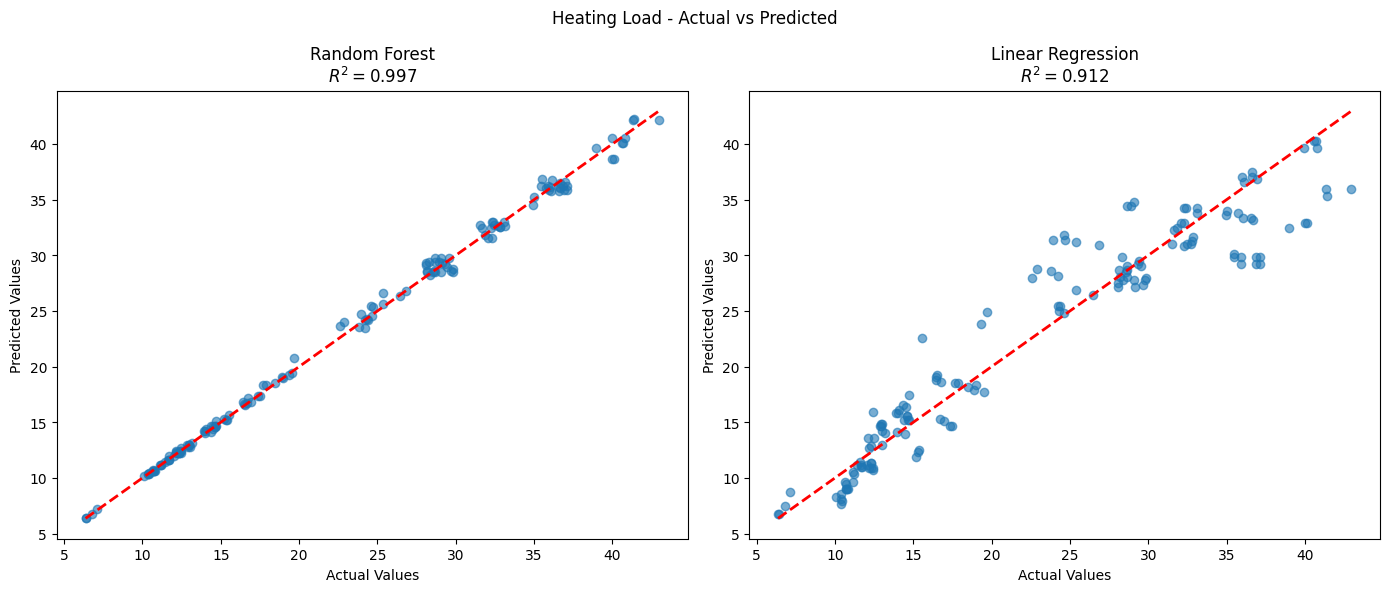

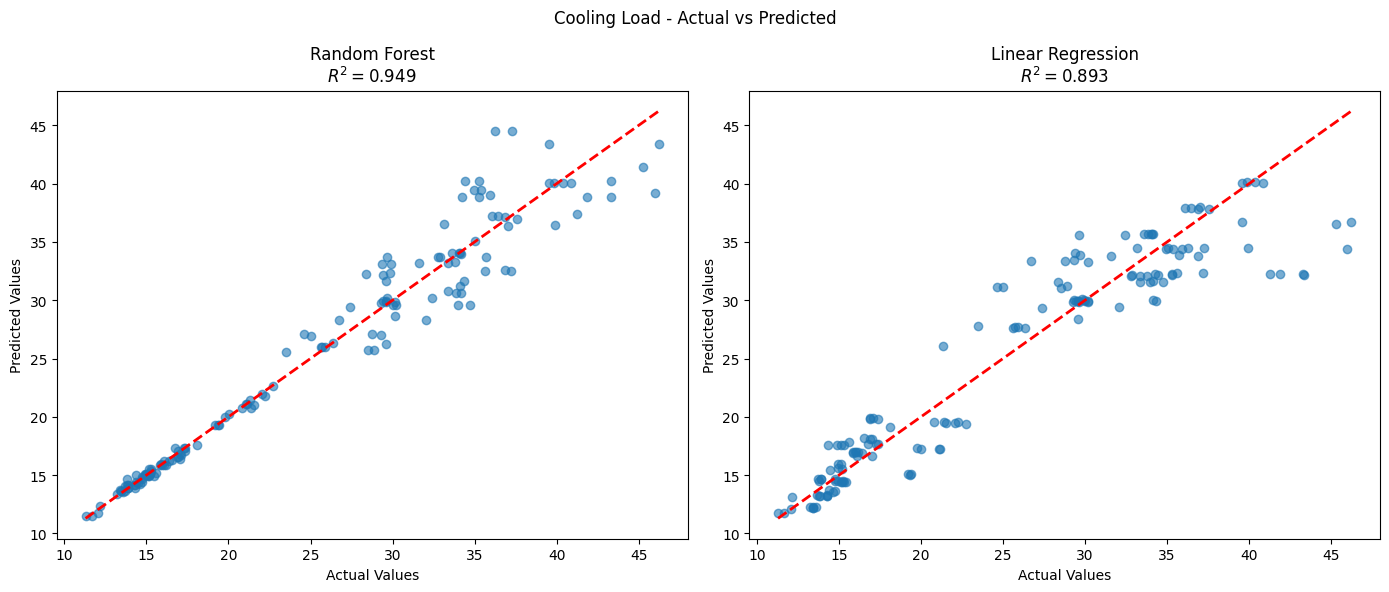

In [ ]:
def plot_actual_vs_predicted(results, y_test, title):

    # Only keeping Linear Regression and Random Forest
    selected_models = {
        name: pred for name, pred in results.items()
        if name in ['Linear Regression', 'Random Forest']
    }
    
    # defining plot size 
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    # flatten
    axes = axes.ravel()
    
    # loop thoguth each model
    for idx, (name, y_pred) in enumerate(selected_models.items()):
        # create scatter plot for the model
        axes[idx].scatter(y_test, y_pred, alpha=0.6)
        
        # define x and y coordinates from small to largest value
        axes[idx].plot(
            [y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', lw=2
        )
        # Assiging labels 
        axes[idx].set_xlabel('Actual Values')
        axes[idx].set_ylabel('Predicted Values')
        axes[idx].set_title(f'{name}\n$R^2 = {r2_score(y_test, y_pred):.3f}$')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_actual_vs_predicted(results_heating, y1_test, "Heating Load - Actual vs Predicted")
plot_actual_vs_predicted(results_cooling, y2_test, "Cooling Load - Actual vs Predicted")

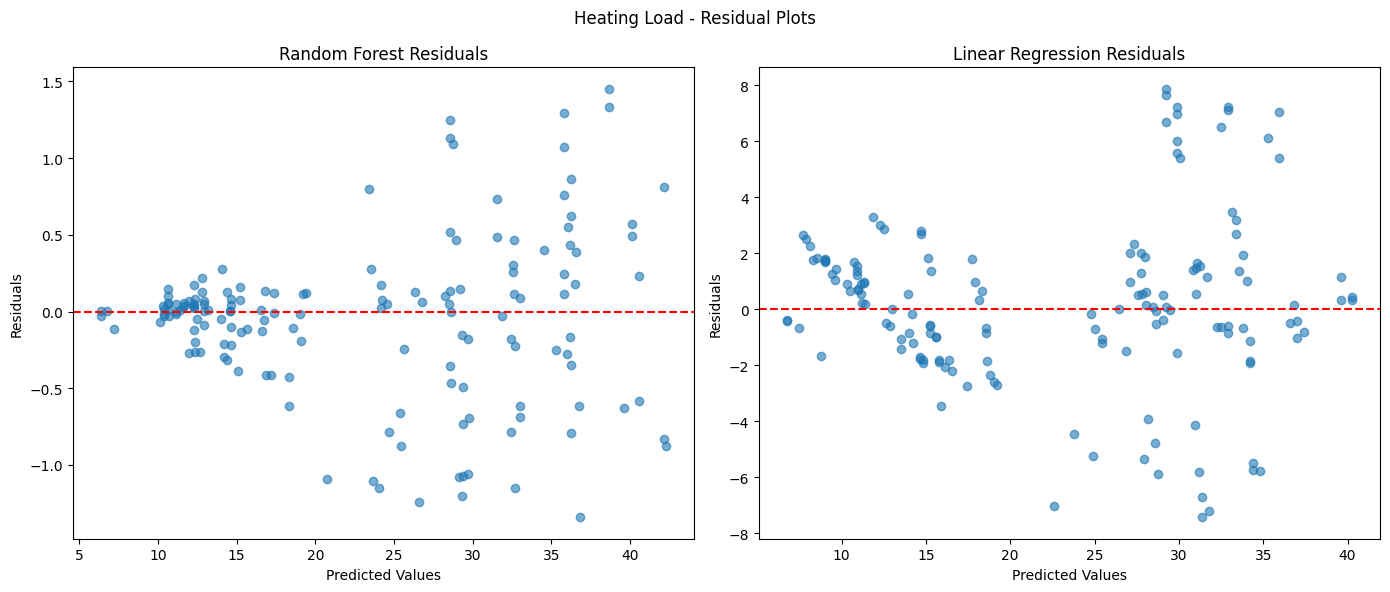

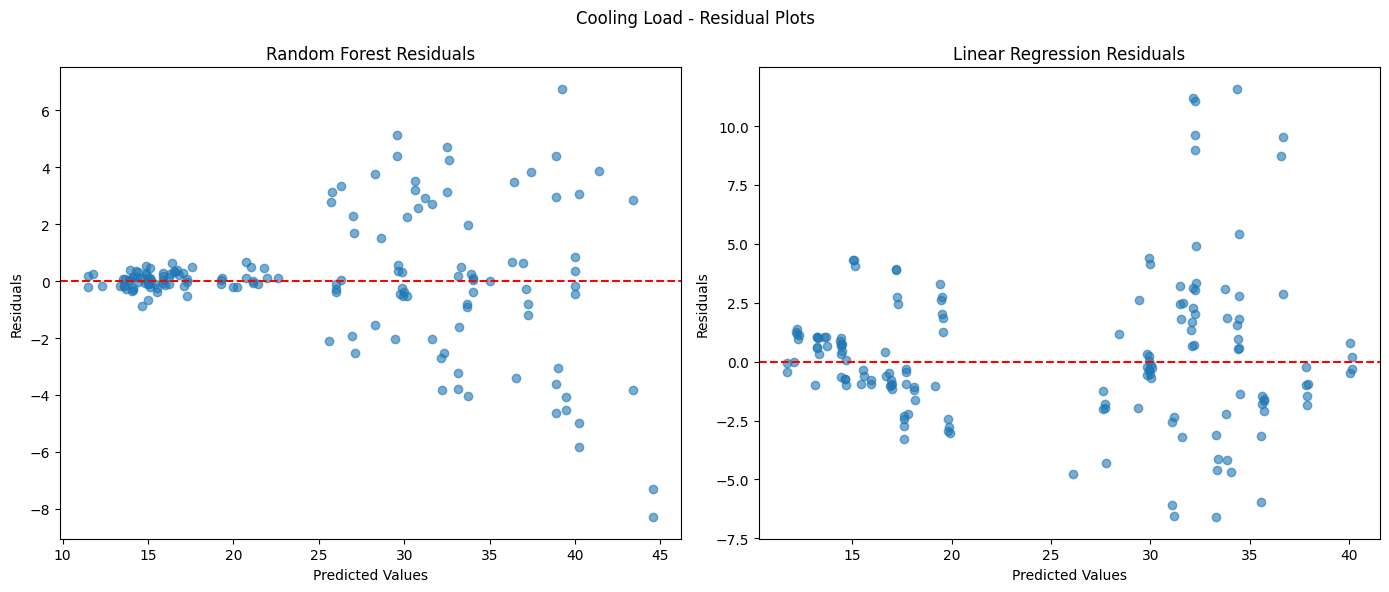

In [ ]:
def plot_residuals(results, y_test, title):

    # Keeping only LM and RF
    selected_models = {
        name: pred for name, pred in results.items()
        if name in ['Linear Regression', 'Random Forest']
    }
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes = axes.ravel()
    
    for idx, (name, y_pred) in enumerate(selected_models.items()):
        residuals = y_test - y_pred

        axes[idx].scatter(y_pred, residuals, alpha=0.6)
        axes[idx].axhline(0, color='red', linestyle='--')
        
        axes[idx].set_xlabel('Predicted Values')
        axes[idx].set_ylabel('Residuals')
        axes[idx].set_title(f'{name} Residuals')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_residuals(results_heating, y1_test, "Heating Load - Residual Plots")
plot_residuals(results_cooling, y2_test, "Cooling Load - Residual Plots")



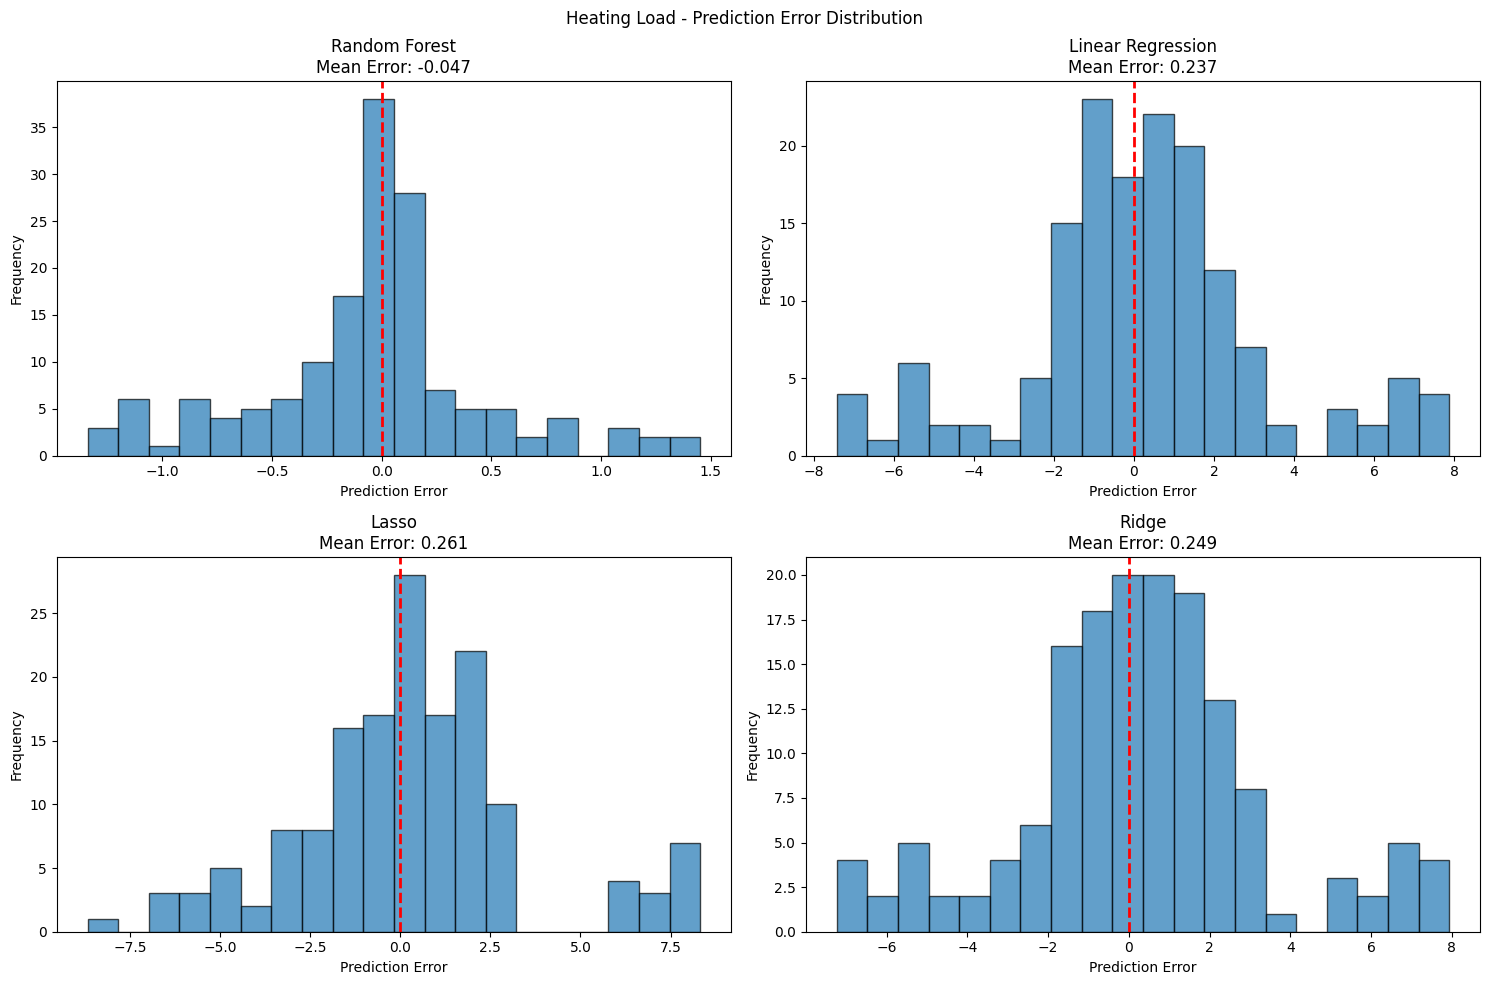

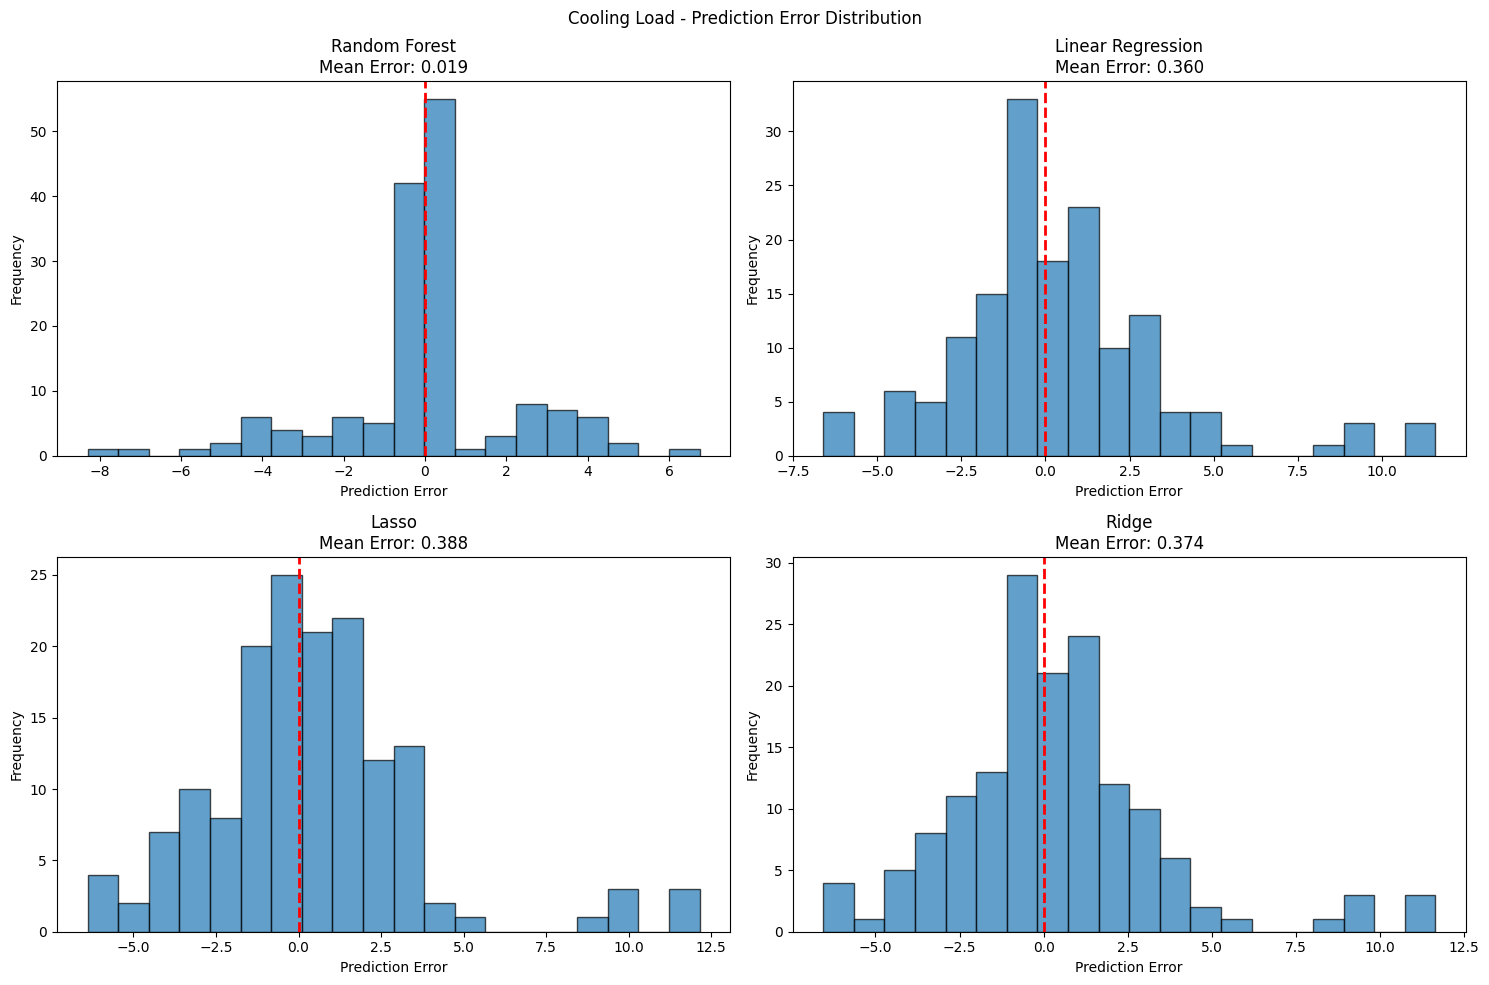

In [ ]:
def plot_error_distribution(results, y_test, title):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.ravel()
    
    for idx, (name, y_pred) in enumerate(results.items()):
        errors = y_test - y_pred
        axes[idx].hist(errors, bins=20, alpha=0.7, edgecolor='black')
        axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2)
        axes[idx].set_xlabel('Prediction Error')
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'{name}\nMean Error: {errors.mean():.3f}')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_error_distribution(results_heating, y1_test, "Heating Load - Prediction Error Distribution")
plot_error_distribution(results_cooling, y2_test, "Cooling Load - Prediction Error Distribution")

In [ ]:
def build_metrics_table(results, y_test):

    rows = []
    for name, y_pred in results.items():
        rows.append({
            'Model': name,
            'R²': r2_score(y_test, y_pred),
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
        })
    
    df = pd.DataFrame(rows).set_index('Model')
    return df


In [ ]:
table_heating = build_metrics_table(results_heating, y1_test)
print(table_heating)

                         R²       MAE      RMSE
Model                                          
Random Forest      0.997442  0.352686  0.516390
Linear Regression  0.912213  2.184008  3.024936
Lasso              0.904646  2.294487  3.152622
Ridge              0.911406  2.201955  3.038803


- For the metrics $R^2$ we the closer to 1.0 the better.
- For MAE The lower the better
- RMSE the lower the better 

In [ ]:
table_cooling = build_metrics_table(results_cooling, y2_test)
print(table_cooling)

                         R²       MAE      RMSE
Model                                          
Random Forest      0.948544  1.343321  2.183524
Linear Regression  0.892667  2.202325  3.153598
Lasso              0.883906  2.305172  3.279774
Ridge              0.892172  2.203044  3.160856
